# Crop Prediction Using Standard Normalization, Stacking, and Blending


In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print('Libraries imported successfully.')

Libraries imported successfully.


In [21]:
# Step 1: Load dataset
df = pd.read_csv('final_cleaned_data.csv')

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (3100, 15)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil_acidic soil,Soil_alkaline soil,Soil_loamy soil,Soil_neutral soil,Soil_peaty soil,target_crop,target_fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,0,0,1,0,0,24,1
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,0,0,1,0,0,24,0
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,0,0,0,0,1,24,9
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,0,0,1,0,0,24,0
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,0,0,0,0,1,24,7


In [22]:
# Step 2: Check columns and missing values
print('Columns:\n', df.columns.tolist())

missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if (missing > 0).any() else 'No missing values found.')

Columns:
 ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil_acidic soil', 'Soil_alkaline soil', 'Soil_loamy soil', 'Soil_neutral soil', 'Soil_peaty soil', 'target_crop', 'target_fertilizer']

Missing values per column:
No missing values found.


In [23]:
# Step 3: Define target and normalization columns
target_col = 'target_crop'

normalize_cols = [
    'Temperature', 'Moisture', 'Rainfall', 'PH',
    'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon',
    'target_fertilizer'
]

required_cols = normalize_cols + [target_col]
missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

print('Target column:', target_col)
print('Columns selected for standard normalization:', normalize_cols)

Target column: target_crop
Columns selected for standard normalization: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'target_fertilizer']


In [24]:
# Step 4: Apply standard normalization
# We scale only the requested columns and keep other columns unchanged.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[normalize_cols] = scaler.fit_transform(df_scaled[normalize_cols])

print('Normalized sample:')
display(df_scaled[normalize_cols].head())

Normalized sample:


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,target_fertilizer
0,2.513859,0.863419,1.271981,-0.159275,0.532500,0.124635,0.757621,-1.622128,-1.067074
1,-0.618654,0.836268,2.688407,0.829048,1.011789,2.349738,2.341780,-0.456692,-1.381606
2,-0.461993,0.586431,2.029464,1.046052,1.416954,-0.259734,0.263672,0.429941,1.449179
3,-0.112929,1.064917,1.372104,0.526248,1.645124,2.038432,2.491231,-0.009253,-1.381606
4,-0.634363,0.896398,2.162681,1.252926,1.029640,-0.152067,0.775142,0.409939,0.820116


In [25]:
# Quick check of mean ~ 0 and std ~ 1 after scaling
stats = pd.DataFrame({
    'mean': df_scaled[normalize_cols].mean(),
    'std': df_scaled[normalize_cols].std()
})
display(stats)

,mean,std
Temperature,2.017025e-16,1.000161
Moisture,3.896525e-17,1.000161
Rainfall,-1.650293e-16,1.000161
PH,1.329403e-16,1.000161
Nitrogen,-4.034049e-16,1.000161
Phosphorous,7.334635e-17,1.000161
Potassium,-5.500976e-17,1.000161
Carbon,1.123116e-16,1.000161
target_fertilizer,-4.584147e-18,1.000161


In [26]:
# Step 5: Prepare features and target for modeling
# float32 cuts memory usage roughly in half compared to float64.
X = df_scaled.drop(columns=[target_col]).astype(np.float32)
y = df_scaled[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('Unique classes in target_crop:', y.nunique())

X_train shape: (2480, 14)
X_test shape : (620, 14)
Unique classes in target_crop: 31


## Stacking Method

In [27]:
# Step 6: Define base and meta models for stacking
# Memory-safe setup: keep multiple learners but avoid heavy parallel workers.
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=120, n_jobs=1, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=9, weights='distance')),
    ('gnb', GaussianNB()),
    ('dt', DecisionTreeClassifier(max_depth=12, random_state=42))
]

meta_model = LogisticRegression(max_iter=2000, multi_class='auto')

stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    stack_method='predict_proba',
    cv=3,
    n_jobs=1,
    passthrough=False
)

print(f'Stacking model initialized with {len(base_estimators)} base learners.')

Stacking model initialized with 6 base learners.


In [28]:
# Step 7: Train and evaluate stacking model
try:
    stack_model.fit(X_train, y_train)
except MemoryError:
    print('MemoryError detected. Retrying with a lighter stacking setup...')
    light_base_estimators = [
        ('rf', RandomForestClassifier(n_estimators=80, n_jobs=1, random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=80, n_jobs=1, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('gnb', GaussianNB())
    ]
    stack_model = StackingClassifier(
        estimators=light_base_estimators,
        final_estimator=meta_model,
        stack_method='predict_proba',
        cv=3,
        n_jobs=1,
        passthrough=False
    )
    stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)
print(f'Stacking Accuracy: {stack_acc:.4f}')
print('\nStacking Classification Report:')
print(classification_report(y_test, stack_pred))

Stacking Accuracy: 0.5823

Stacking Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.59      0.50      0.54        20
           2       0.54      0.75      0.62        20
           3       0.71      0.50      0.59        20
           4       0.78      0.70      0.74        20
           5       0.61      0.70      0.65        20
           6       0.54      0.35      0.42        20
           7       0.44      0.35      0.39        20
           8       0.50      0.65      0.57        20
           9       0.53      0.50      0.51        20
          10       0.70      0.70      0.70        20
          11       0.74      0.85      0.79        20
          12       0.50      0.35      0.41        20
          13       0.32      0.35      0.33        20
          14       0.46      0.65      0.54        20
          15       0.95      0.90      0.92        20
          16       0.7

## Blending Method

In [29]:
# Step 8: Create train-blend split from training data
X_base, X_blend, y_base, y_blend = train_test_split(
    X_train, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

print('Base training part :', X_base.shape)
print('Blending validation:', X_blend.shape)

Base training part : (1736, 14)
Blending validation: (744, 14)


In [30]:
# Step 9: Train base models for blending
from sklearn.tree import DecisionTreeClassifier

blend_base_models = [
    RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=42),
    ExtraTreesClassifier(n_estimators=120, n_jobs=1, random_state=42),
    GradientBoostingClassifier(random_state=42),
    KNeighborsClassifier(n_neighbors=9, weights='distance'),
    GaussianNB(),
    DecisionTreeClassifier(max_depth=12, random_state=42)
]

for model in blend_base_models:
    model.fit(X_base, y_base)

print(f'Base models trained for blending: {len(blend_base_models)}')

Base models trained for blending: 6


In [31]:
# Step 10: Build meta-features using probability outputs
if 'blend_base_models' not in globals():
    print('blend_base_models not found. Re-running Step 9 setup...')
    from sklearn.tree import DecisionTreeClassifier
    blend_base_models = [
        RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=42),
        ExtraTreesClassifier(n_estimators=120, n_jobs=1, random_state=42),
        GradientBoostingClassifier(random_state=42),
        KNeighborsClassifier(n_neighbors=9, weights='distance'),
        GaussianNB(),
        DecisionTreeClassifier(max_depth=12, random_state=42)
    ]
    for model in blend_base_models:
        model.fit(X_base, y_base)

blend_meta_train = np.column_stack([
    model.predict_proba(X_blend) for model in blend_base_models
]).astype(np.float32)

blend_meta_test = np.column_stack([
    model.predict_proba(X_test) for model in blend_base_models
]).astype(np.float32)

print('Meta-feature train shape:', blend_meta_train.shape)
print('Meta-feature test shape :', blend_meta_test.shape)

Meta-feature train shape: (744, 186)
Meta-feature test shape : (620, 186)


In [32]:
# Step 11: Train meta-model and evaluate blending
blend_meta_model = LogisticRegression(max_iter=2000, multi_class='auto')
blend_meta_model.fit(blend_meta_train, y_blend)

blend_pred = blend_meta_model.predict(blend_meta_test)
blend_acc = accuracy_score(y_test, blend_pred)

print(f'Blending Accuracy: {blend_acc:.4f}')
print('\nBlending Classification Report:')
print(classification_report(y_test, blend_pred))

Blending Accuracy: 0.5661

Blending Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.52      0.60      0.56        20
           2       0.52      0.70      0.60        20
           3       0.56      0.70      0.62        20
           4       0.71      0.75      0.73        20
           5       0.71      0.60      0.65        20
           6       0.56      0.45      0.50        20
           7       0.25      0.20      0.22        20
           8       0.41      0.55      0.47        20
           9       0.50      0.50      0.50        20
          10       0.58      0.55      0.56        20
          11       0.75      0.90      0.82        20
          12       0.50      0.40      0.44        20
          13       0.12      0.10      0.11        20
          14       0.50      0.50      0.50        20
          15       1.00      0.90      0.95        20
          16       0.7

Accuracy Report:


,Model,Accuracy
0,Stacking,0.582258
1,Blending,0.566129


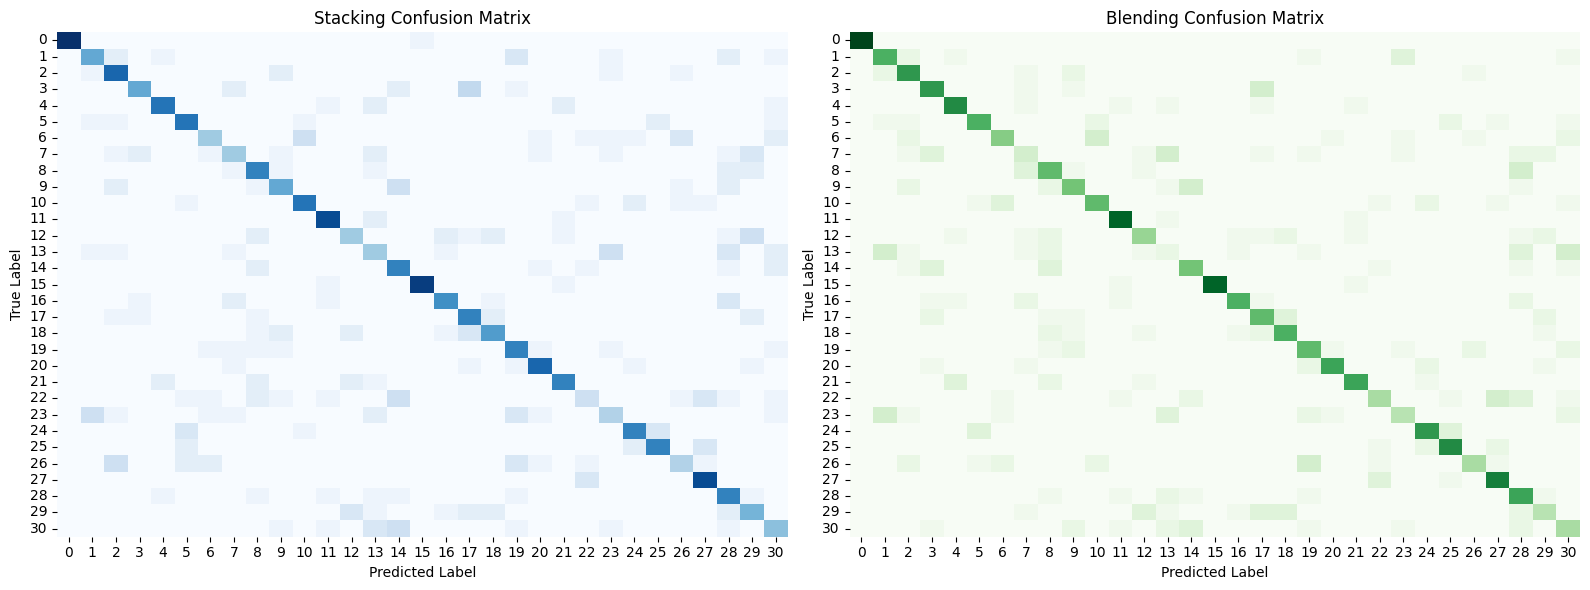

In [33]:
# Step 11.1: Accuracy report and confusion matrix (Seaborn)
accuracy_report = pd.DataFrame({
    'Model': ['Stacking', 'Blending'],
    'Accuracy': [stack_acc, blend_acc]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print('Accuracy Report:')
display(accuracy_report)

stack_cm = confusion_matrix(y_test, stack_pred)
blend_cm = confusion_matrix(y_test, blend_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(stack_cm, cmap='Blues', annot=False, fmt='d', cbar=False, ax=axes[0])
axes[0].set_title('Stacking Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(blend_cm, cmap='Greens', annot=False, fmt='d', cbar=False, ax=axes[1])
axes[1].set_title('Blending Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [34]:
# Step 12: Final comparison
comparison = pd.DataFrame({
    'Method': ['Stacking', 'Blending'],
    'Accuracy': [stack_acc, blend_acc]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison)

best_method = comparison.loc[0, 'Method']
best_score = comparison.loc[0, 'Accuracy']
print(f'Best method on this split: {best_method} (Accuracy = {best_score:.4f})')

,Method,Accuracy
0,Stacking,0.582258
1,Blending,0.566129


Best method on this split: Stacking (Accuracy = 0.5823)
